<a href="https://colab.research.google.com/github/neurostatslab/error-in-variables-garon-2026/blob/main/demo_notebooks/002_runtime_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture

!git clone https://github.com/neurostatslab/error-in-variables-garon-2026.git
import sys
sys.path.append('error-in-variables-garon-2026/')

In [2]:
%%capture
!pip install -U "jax[cuda12]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

!pip install jaxopt
!pip install distrax

import jax
import jaxopt
import jax.numpy as jnp
from jax.nn import softplus
from jax.scipy.special import logsumexp

import matplotlib.pyplot as plt

from functools import partial
import time

import utils
import mappings
import noise_models
from core import EIV
from mc_samplers import Roberts


In [3]:
# KEY DUMP
GEN_KEY = jax.random.PRNGKey(8)
INIT_KEY = jax.random.PRNGKey(11)
OPT_KEY = jax.random.PRNGKey(123)
TEST_KEY = jax.random.PRNGKey(777)

# Small Simulation: N = 100, T = 3000


### Simulate Data

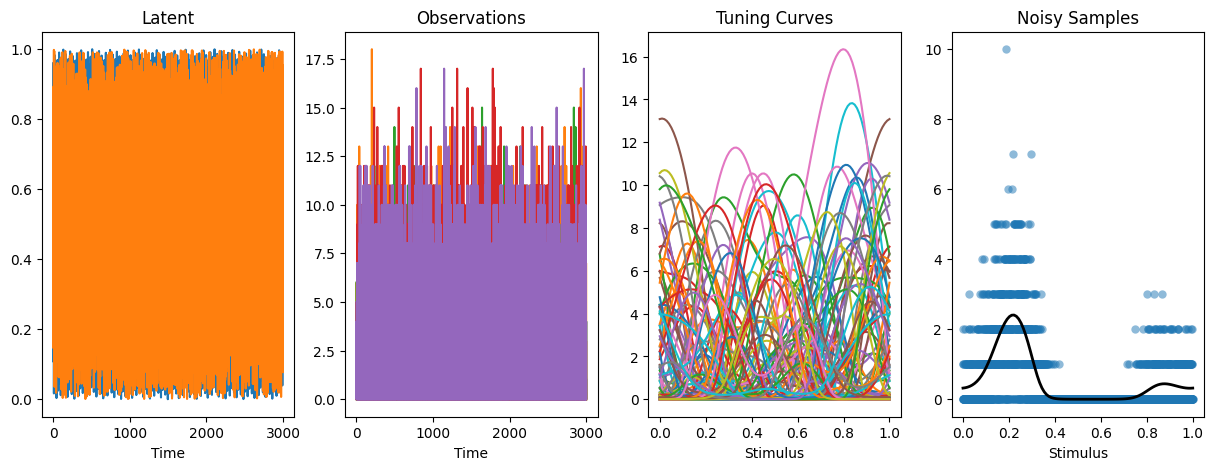

In [4]:
# Generative Hyperparams
num_neurons = 100
num_dims = 1
num_steps = 3000

# Construct Model
model = EIV(len_scale = .2,
            out_scale = 50.,
            kappa = 7.,
            num_dims=num_dims,
            num_neurons=num_neurons)

# Simulate Data
xs_true, ys = model.simulate(
    num_steps=num_steps
)

# Visualize Data
utils.plot_simulated_data_1D(xs_true, model.true_params, ys, model);

### Fit Model

In [5]:
# Adjust run params, set up minibatching
opt_params = {
        "opt_key": OPT_KEY,
        "init_key": INIT_KEY,
        "tol_loss":1e-4,
        "minibatch":True,
        "batch_size":1000,
        "lr": 1e0
    }

start_time = time.perf_counter()

model.fit(ys, "adam", opt_params)
jax.block_until_ready(model.params_)

end_time = time.perf_counter()

print("\n\n #### " , jax.devices()[0].platform, "(", jax.devices()[0].device_kind,")")
print("| Method | Datascale | Very small (N=", num_neurons, "T=",num_steps)
print("|-----|------------------------------------------:|")
print("| EIV | ", str(end_time - start_time), " secs")




 ####  gpu ( NVIDIA A100-SXM4-80GB )
| Method | Datascale | Very small (N= 100 T= 3000
|-----|------------------------------------------:|
| EIV |  4.346711377999782  secs


### Plot Results

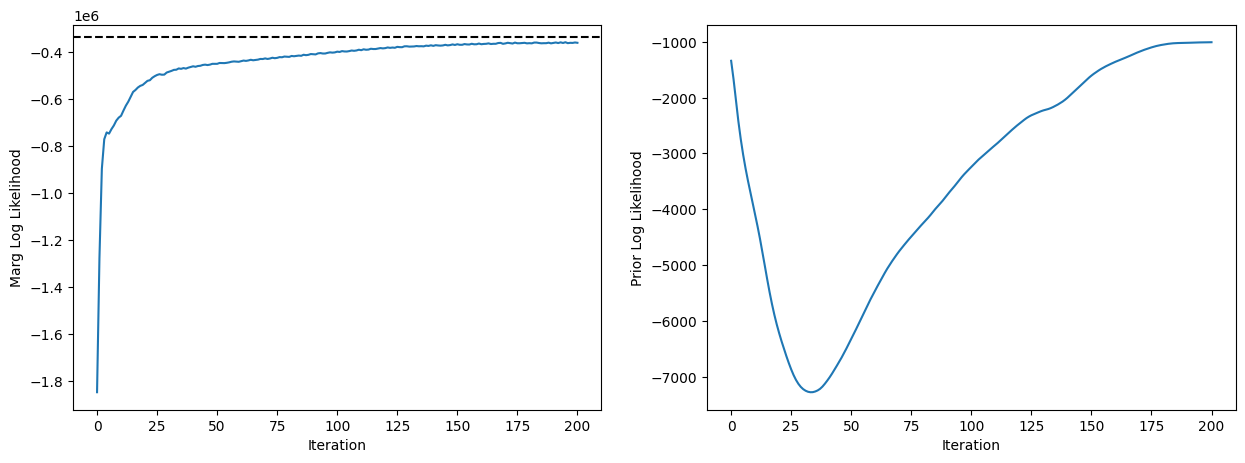

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


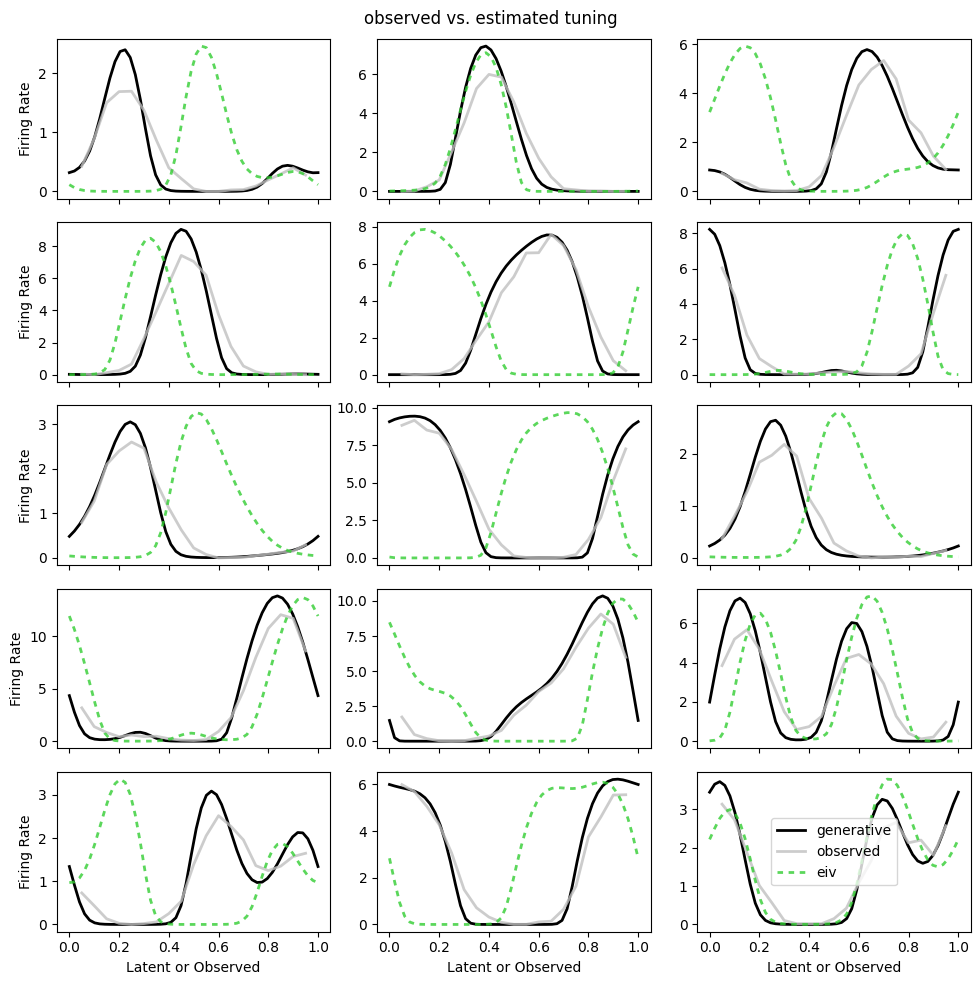

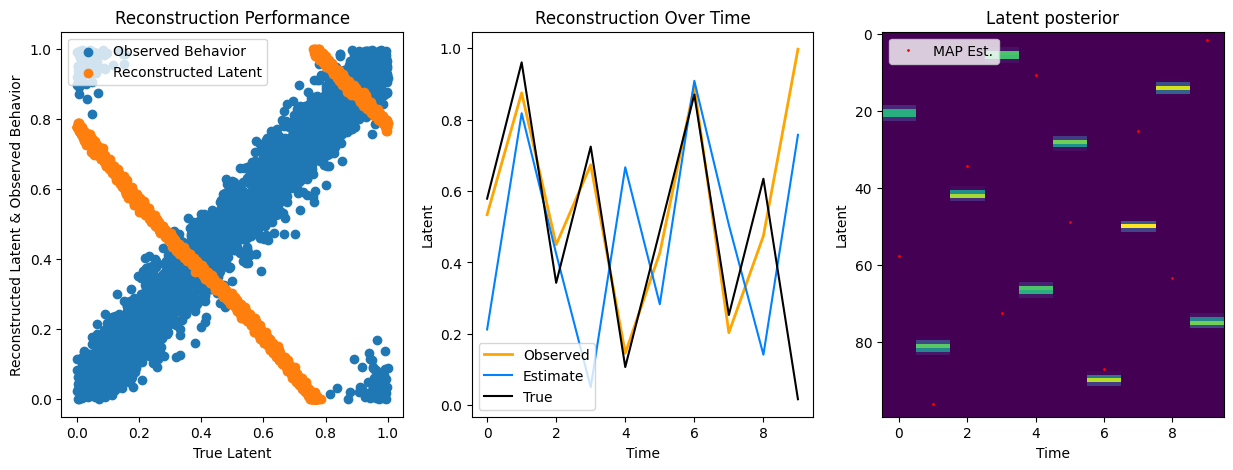

In [6]:
utils.plot_objhist_sim(model, ys, TEST_KEY)

x_grid = jnp.linspace(0, 1, 50)[:, None]
true_tunings = model.observation.mapping(model.true_params, x_grid)[0].T
utils.plot_real_tuning(model, true_tunings, ys, grid_max = 1, grid_reso=50);
utils.plot_latent_recon_sim(model, ys, xs_true, window = 10);

# Medium Simulation: N = 250, T = 72000

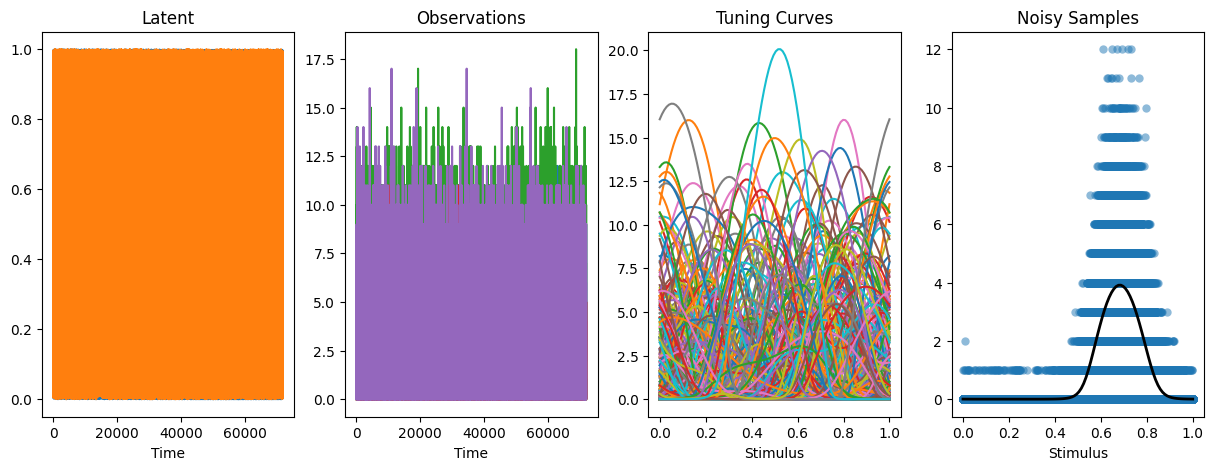

In [15]:
# Generative Hyperparams
num_neurons = 250
num_dims = 1
num_steps = 72000

# Construct Model
model = EIV(len_scale = .2,
            out_scale = 50.,
            kappa = 5.,
            num_dims=num_dims,
            num_neurons=num_neurons)

# Simulate Data
xs_true, ys = model.simulate(
    num_steps=num_steps
)

# Visualize Data
utils.plot_simulated_data_1D(xs_true, model.true_params, ys, model);

### Fit Model

In [16]:
# Adjust run params, set up minibatching
opt_params = {
        "opt_key": OPT_KEY,
        "init_key": INIT_KEY,
        "tol_loss":1e-4,
        "minibatch":True,
        "batch_size":1000,
        "lr": 1e0
}

start_time = time.perf_counter()

model.fit(ys, "adam", opt_params)
jax.block_until_ready(model.params_)

end_time = time.perf_counter()

print("\n\n #### " , jax.devices()[0].platform, "(", jax.devices()[0].device_kind,")")
print("| Method | Datascale | Medium (N =", num_neurons, "T =",num_steps)
print("|-----|------------------------------------------:|")
print("| EIV | ", str(end_time - start_time), " secs")




 ####  gpu ( NVIDIA A100-SXM4-80GB )
| Method | Datascale | Medium (N = 250 T = 72000
|-----|------------------------------------------:|
| EIV |  1.4688613430002988  secs


### Plot Results

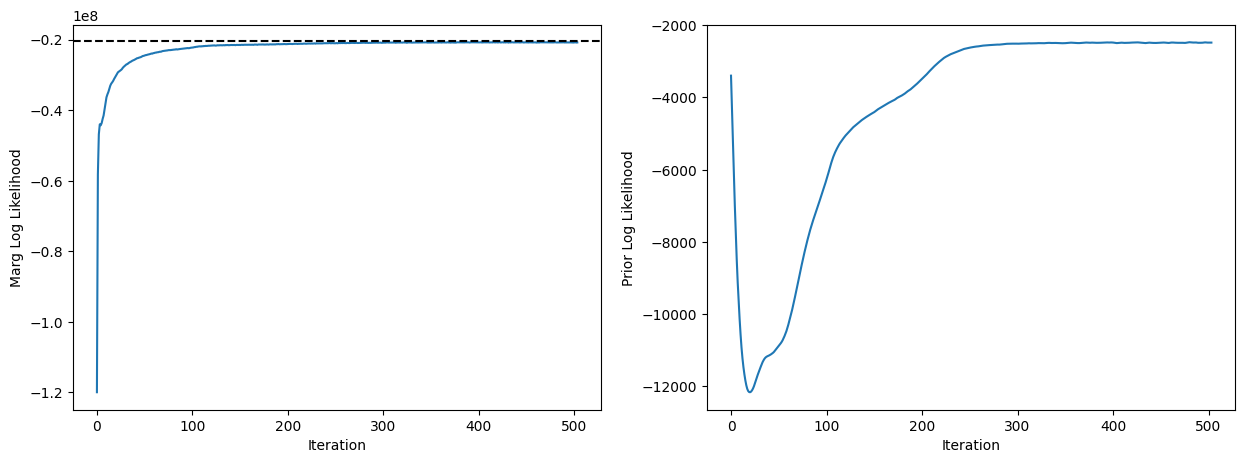

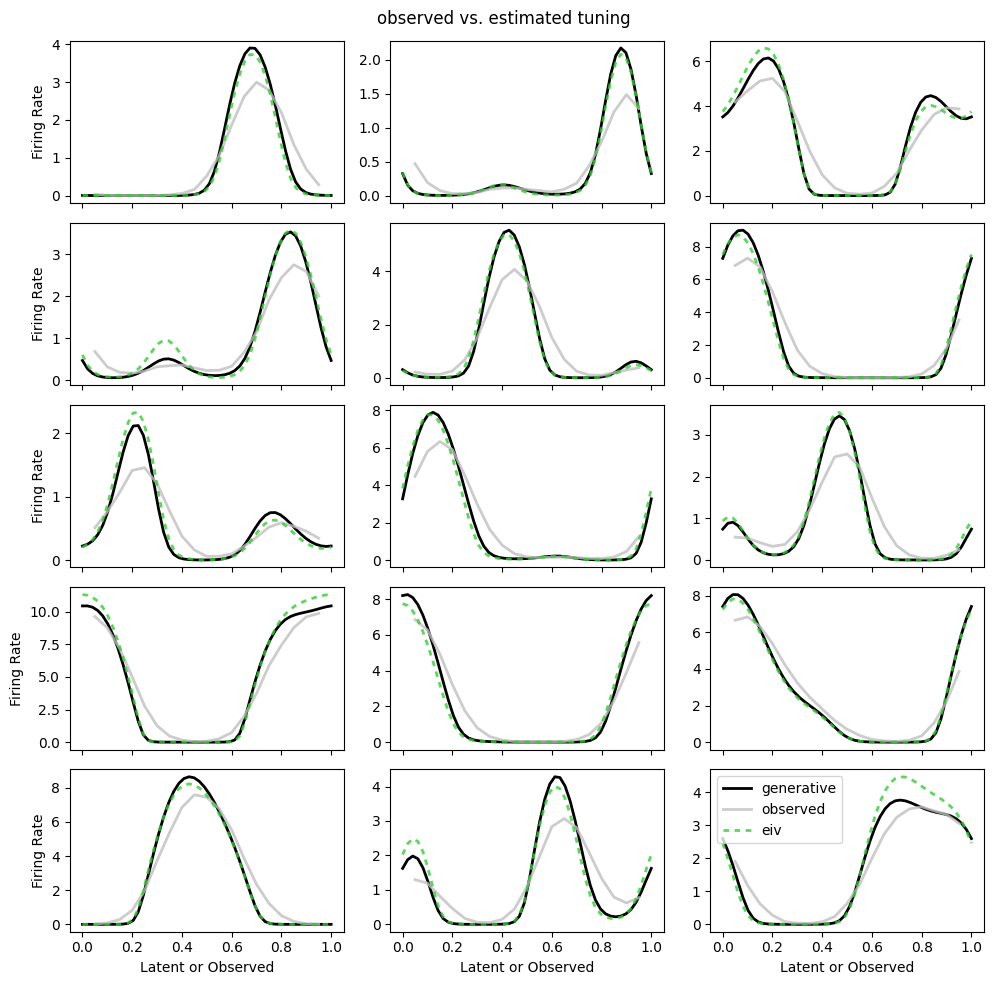

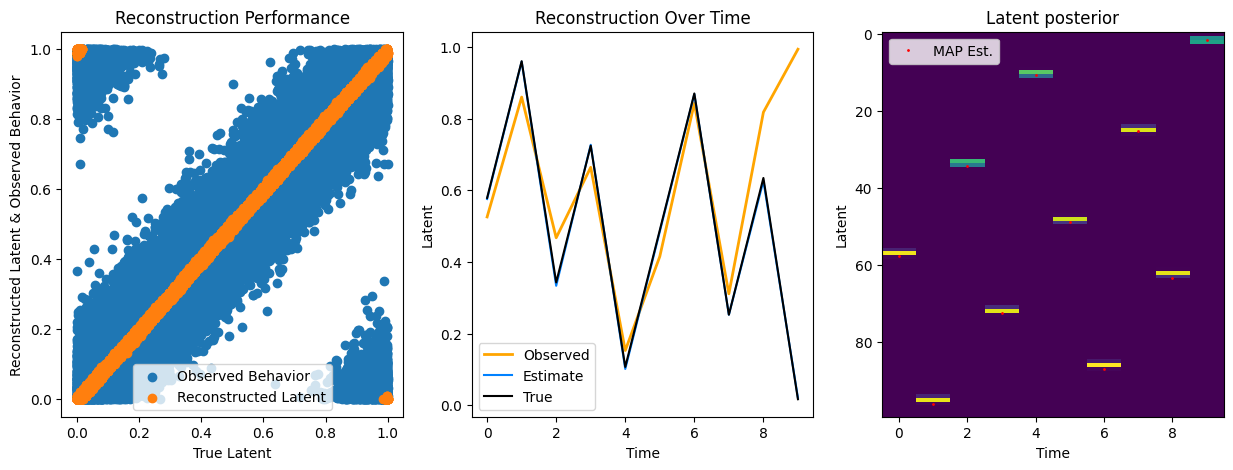

In [17]:
utils.plot_objhist_sim(model, ys, TEST_KEY)

x_grid = jnp.linspace(0, 1, 50)[:, None]
true_tunings = model.observation.mapping(model.true_params, x_grid)[0].T
utils.plot_real_tuning(model, true_tunings, ys, grid_max = 1, grid_reso=50);

utils.plot_latent_recon_sim(model, ys, xs_true, window = 10);

# Large Simulation: N = 600, T = 500000

In [12]:
# Generative Hyperparams
num_neurons = 600
num_dims = 1
num_steps = 500000

# Construct Model
model = EIV(len_scale = .2,
            out_scale = 50.,
            kappa = 5.,
            num_dims=num_dims,
            num_neurons=num_neurons)

# Simulate Data
xs_true, ys = model.simulate(
    num_steps=num_steps
)

### Fit Model

In [13]:
# Adjust run params, set up minibatching
opt_params = {
        "opt_key": OPT_KEY,
        "init_key": INIT_KEY,
        "tol_loss":1e-3,
        "minibatch":True,
        "batch_size":1000,
        "lr": 1e0
    }

start_time = time.perf_counter()

model.fit(ys, "adam", opt_params)
jax.block_until_ready(model.params_)

end_time = time.perf_counter()


print("\n\n #### " , jax.devices()[0].platform, "(", jax.devices()[0].device_kind,")")
print("| Method | Datascale | Large (N =", num_neurons, "T =",num_steps)
print("|-----|------------------------------------------:|")
print("| EIV | ", str(end_time - start_time), " secs")





 ####  gpu ( NVIDIA A100-SXM4-80GB )
| Method | Datascale | Large (N = 600 T = 500000
|-----|------------------------------------------:|
| EIV |  8.445578282000042  secs


### Plot Results

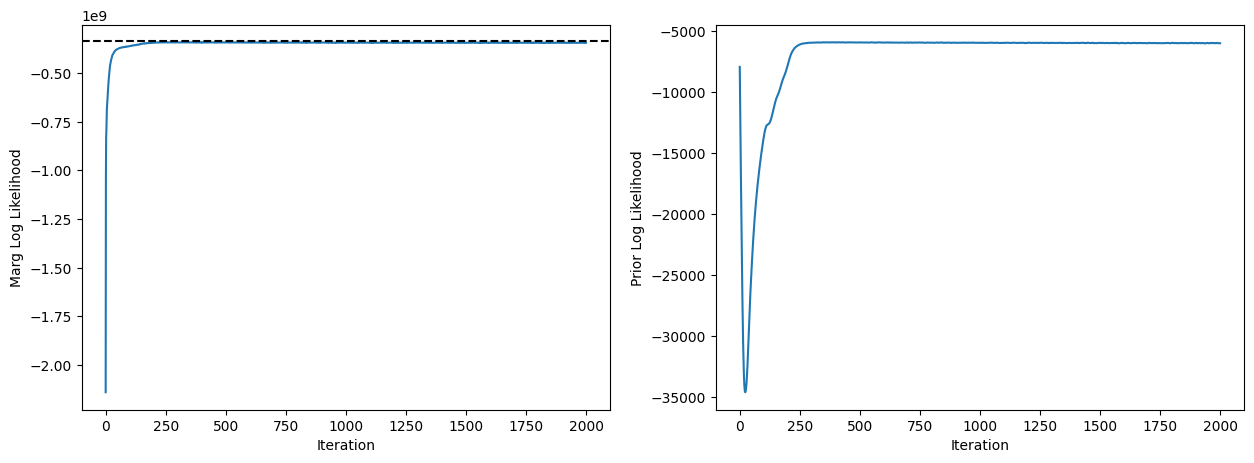

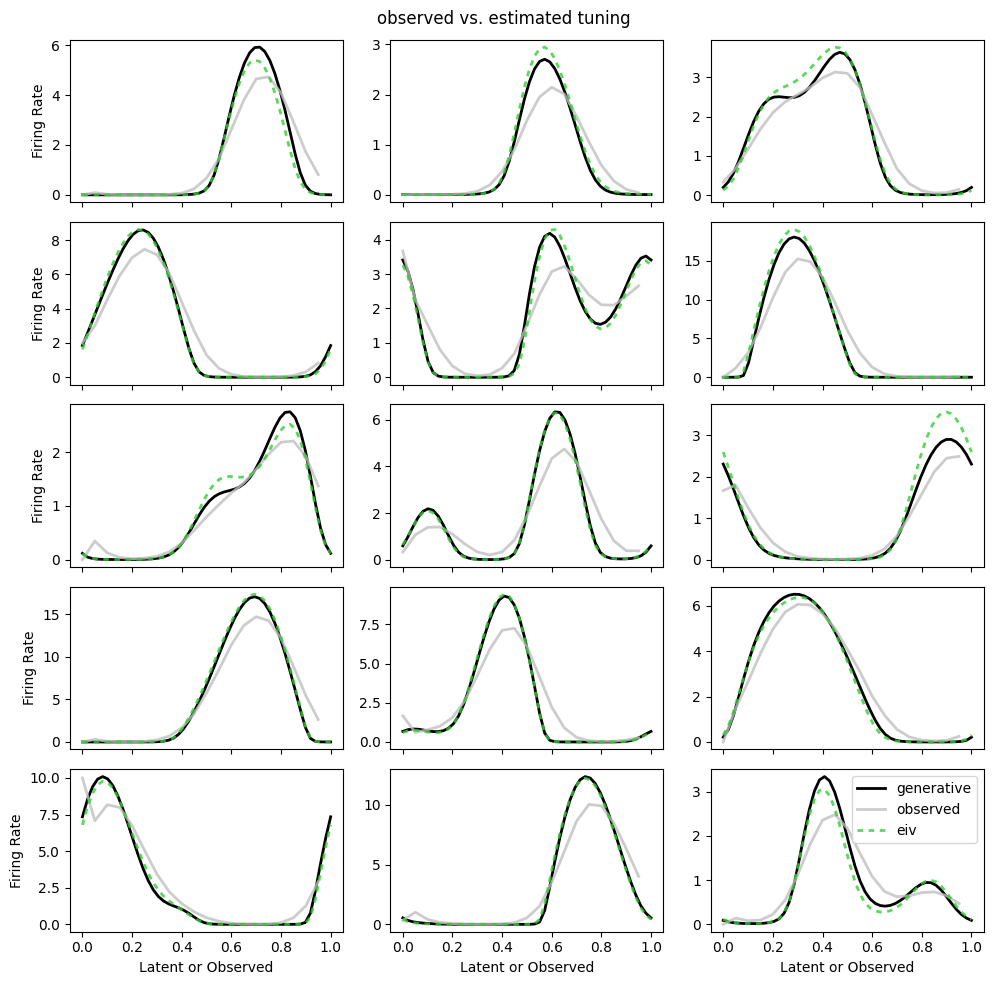

In [14]:
utils.plot_objhist_sim(model, ys, TEST_KEY)

x_grid = jnp.linspace(0, 1, 50)[:, None]
true_tunings = model.observation.mapping(model.true_params, x_grid)[0].T
utils.plot_real_tuning(model, true_tunings, ys, grid_max = 1, grid_reso=50);
